In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from skimpy import skim
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report


In [2]:
df = pd.read_csv("enhanced_health_insurance_claims.csv")
df.head()

,ClaimID,PatientID,ProviderID,ClaimAmount,ClaimDate,DiagnosisCode,ProcedureCode,PatientAge,PatientGender,ProviderSpecialty,ClaimStatus,PatientIncome,PatientMaritalStatus,PatientEmploymentStatus,ProviderLocation,ClaimType,ClaimSubmissionMethod
0,10944daf-f7d5-4e1d-8216-72ffa609fe41,8552381d-7960-4f64-b190-b20b8ada00a1,4a4cb19c-4863-41cf-84b0-c2b21aace988,3807.95,2024-06-07,yy006,hd662,16,M,Cardiology,Pending,90279.43,Married,Retired,Jameshaven,Routine,Paper
1,fcbebb25-fc24-4c0f-a966-749edcf83fb1,327f43ad-e3bd-4473-a9ed-46483a0a156f,422e02dd-c1fd-43dd-8af4-0c3523f997b1,9512.07,2023-05-30,tD052,mH831,27,M,Pediatrics,Approved,130448.02,Single,Student,Beltrantown,Routine,Online
2,9e9983e7-9ea7-45f5-84d8-ce49ccd8a4a1,6f3acdf7-73aa-4afa-9c2e-b25b27bdb5b0,f7733b3f-0980-47b5-a7a0-ee390869355b,7346.74,2022-09-27,zx832,dg637,40,F,Cardiology,Pending,82417.54,Divorced,Employed,West Charlesport,Emergency,Online
3,a06273ed-44bb-452b-bbad-8618de080494,5d58e183-701e-406c-a8c6-5b73cac5e912,f7a04581-de96-44ee-b773-8adac02baa59,6026.72,2023-06-25,kr421,kG326,65,M,Neurology,Pending,68516.96,Widowed,Student,West Aprilhaven,Routine,Phone
4,f702a717-254b-4cff-a0c7-8395db2f6616,8a8ebdf6-3af0-4f14-82f3-37b937c3d270,b80b9e77-97f0-47d7-b561-19f9658a7bdf,1644.58,2023-07-24,LZ261,cx805,24,M,General Practice,Pending,84122.17,Married,Student,Lake Michele,Inpatient,Phone


In [3]:
drop_cols = [
    "ClaimID",
    "PatientID",
    "ProviderID",
]

df = df.drop(columns=drop_cols)

In [4]:
df.head()

,ClaimAmount,ClaimDate,DiagnosisCode,ProcedureCode,PatientAge,PatientGender,ProviderSpecialty,ClaimStatus,PatientIncome,PatientMaritalStatus,PatientEmploymentStatus,ProviderLocation,ClaimType,ClaimSubmissionMethod
0,3807.95,2024-06-07,yy006,hd662,16,M,Cardiology,Pending,90279.43,Married,Retired,Jameshaven,Routine,Paper
1,9512.07,2023-05-30,tD052,mH831,27,M,Pediatrics,Approved,130448.02,Single,Student,Beltrantown,Routine,Online
2,7346.74,2022-09-27,zx832,dg637,40,F,Cardiology,Pending,82417.54,Divorced,Employed,West Charlesport,Emergency,Online
3,6026.72,2023-06-25,kr421,kG326,65,M,Neurology,Pending,68516.96,Widowed,Student,West Aprilhaven,Routine,Phone
4,1644.58,2023-07-24,LZ261,cx805,24,M,General Practice,Pending,84122.17,Married,Student,Lake Michele,Inpatient,Phone


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4500 entries, 0 to 4499
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   ClaimAmount              4500 non-null   float64
 1   ClaimDate                4500 non-null   object 
 2   DiagnosisCode            4500 non-null   object 
 3   ProcedureCode            4500 non-null   object 
 4   PatientAge               4500 non-null   int64  
 5   PatientGender            4500 non-null   object 
 6   ProviderSpecialty        4500 non-null   object 
 7   ClaimStatus              4500 non-null   object 
 8   PatientIncome            4500 non-null   float64
 9   PatientMaritalStatus     4500 non-null   object 
 10  PatientEmploymentStatus  4500 non-null   object 
 11  ProviderLocation         4500 non-null   object 
 12  ClaimType                4500 non-null   object 
 13  ClaimSubmissionMethod    4500 non-null   object 
dtypes: float64(2), int64(1),

In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
skim(df)

╭──────────────────────────────────────────────── skimpy summary ─────────────────────────────────────────────────╮
│          Data Summary                Data Types                                                                 │
│ ┏━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┓ ┏━━━━━━━━━━━━━┳━━━━━━━┓                                                          │
│ ┃ Dataframe         ┃ Values ┃ ┃ Column Type ┃ Count ┃                                                          │
│ ┡━━━━━━━━━━━━━━━━━━━╇━━━━━━━━┩ ┡━━━━━━━━━━━━━╇━━━━━━━┩                                                          │
│ │ Number of rows    │ 4500   │ │ string      │ 11    │                                                          │
│ │ Number of columns │ 14     │ │ float64     │ 2     │                                                          │
│ └───────────────────┴────────┘ │ int64       │ 1     │                                                          │
│                                └─────────────┴───────┘                                                          │
│                                                     number                                                      │
│ ┏━━━━━━━━━━━━━━━━━━┳━━━━━┳━━━━━━━┳━━━━━━━━━┳━━━━━━━━┳━━━━━━━━┳━━━━━━━━┳━━━━━━━━┳━━━━━━━━━┳━━━━━━━━━┳━━━━━━━━━┓  │
│ ┃ column           ┃ NA  ┃ NA %  ┃ mean    ┃ sd     ┃ p0     ┃ p25    ┃ p50    ┃ p75     ┃ p100    ┃ hist    ┃  │
│ ┡━━━━━━━━━━━━━━━━━━╇━━━━━╇━━━━━━━╇━━━━━━━━━╇━━━━━━━━╇━━━━━━━━╇━━━━━━━━╇━━━━━━━━╇━━━━━━━━━╇━━━━━━━━━╇━━━━━━━━━┩  │
│ │ ClaimAmount      │   0 │     0 │    5014 │   2866 │  100.1 │   2509 │   5054 │    7462 │    9997 │ ▇▇▇▇▇▇  │  │
│ │ PatientAge       │   0 │     0 │   49.84 │  28.79 │      0 │     25 │   50.5 │      75 │      99 │ ▇▇▇▇▇▇  │  │
│ │ PatientIncome    │   0 │     0 │   84380 │  37090 │  20010 │  52790 │  84060 │  115800 │  150000 │ ▇▇▇▇▇▇  │  │
│ └──────────────────┴─────┴───────┴─────────┴────────┴────────┴────────┴────────┴─────────┴─────────┴─────────┘  │
│                                                     string                                                      │
│ ┏━━━━━━━━━━━┳━━━━┳━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━┓  │
│ ┃           ┃    ┃      ┃           ┃           ┃           ┃           ┃ chars per ┃ words per  ┃ total     ┃  │
│ ┃ column    ┃ NA ┃ NA % ┃ shortest  ┃ longest   ┃ min       ┃ max       ┃ row       ┃ row        ┃ words     ┃  │
│ ┡━━━━━━━━━━━╇━━━━╇━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━┩  │
│ │ ClaimDate │  0 │    0 │ 2024-06-0 │ 2024-06-0 │ 2022-07-0 │ 2024-07-0 │        10 │          1 │      4500 │  │
│ │           │    │      │ 7         │ 7         │ 9         │ 8         │           │            │           │  │
│ │ Diagnosis │  0 │    0 │ yy006     │ yy006     │ AB411     │ zz569     │         5 │          1 │      4500 │  │
│ │ Code      │    │      │           │           │           │           │           │            │           │  │
│ │ Procedure │  0 │    0 │ hd662     │ hd662     │ AA395     │ zz788     │         5 │          1 │      4500 │  │
│ │ Code      │    │      │           │           │           │           │           │            │           │  │
│ │ PatientGe │  0 │    0 │ M         │ M         │ F         │ M         │         1 │          1 │      4500 │  │
│ │ nder      │    │      │           │           │           │           │           │            │           │  │
│ │ ProviderS │  0 │    0 │ Neurology │ General   │ Cardiolog │ Pediatric │      11.2 │        1.2 │      5380 │  │
│ │ pecialty  │    │      │           │ Practice  │ y         │ s         │           │            │           │  │
│ │ ClaimStat │  0 │    0 │ Denied    │ Approved  │ Approved  │ Pending   │         7 │          1 │      4500 │  │
│ │ us        │    │      │           │           │           │           │           │            │           │  │
│ │ PatientMa │  0 │    0 │ Single    │ Divorced  │ Divo

In [8]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
ClaimAmount,4500.0,5014.203867,2866.291066,100.12,2509.0725,5053.765,7462.4525,9997.20
PatientAge,4500.0,49.838444,28.790471,0.00,25.0000,50.500,75.0000,99.00
PatientIncome,4500.0,84384.284084,37085.908878,20006.87,52791.9050,84061.205,115768.4175,149957.52


In [9]:
df.describe(include= "all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
ClaimAmount,4500.0,NaN,NaN,NaN,5014.203867,2866.291066,100.12,2509.0725,5053.765,7462.4525,9997.2
ClaimDate,4500,731,2023-06-20,15,NaN,NaN,NaN,NaN,NaN,NaN,NaN
DiagnosisCode,4500,4495,TK486,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ProcedureCode,4500,4495,zW098,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
PatientAge,4500.0,NaN,NaN,NaN,49.838444,28.790471,0.0,25.0,50.5,75.0,99.0
PatientGender,4500,2,F,2282,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ProviderSpecialty,4500,5,Pediatrics,955,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ClaimStatus,4500,3,Approved,1522,NaN,NaN,NaN,NaN,NaN,NaN,NaN
PatientIncome,4500.0,NaN,NaN,NaN,84384.284084,37085.908878,20006.87,52791.905,84061.205,115768.4175,149957.52
PatientMaritalStatus,4500,4,Married,1181,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [10]:
df.corr(numeric_only=True)

,ClaimAmount,PatientAge,PatientIncome
ClaimAmount,1.000000,0.009515,0.019128
PatientAge,0.009515,1.000000,0.017400
PatientIncome,0.019128,0.017400,1.000000


In [11]:
df.nunique()

ClaimAmount                4490
ClaimDate                   731
DiagnosisCode              4495
ProcedureCode              4495
PatientAge                  100
PatientGender                 2
ProviderSpecialty             5
ClaimStatus                   3
PatientIncome              4500
PatientMaritalStatus          4
PatientEmploymentStatus       4
ProviderLocation           3876
ClaimType                     4
ClaimSubmissionMethod         3
dtype: int64

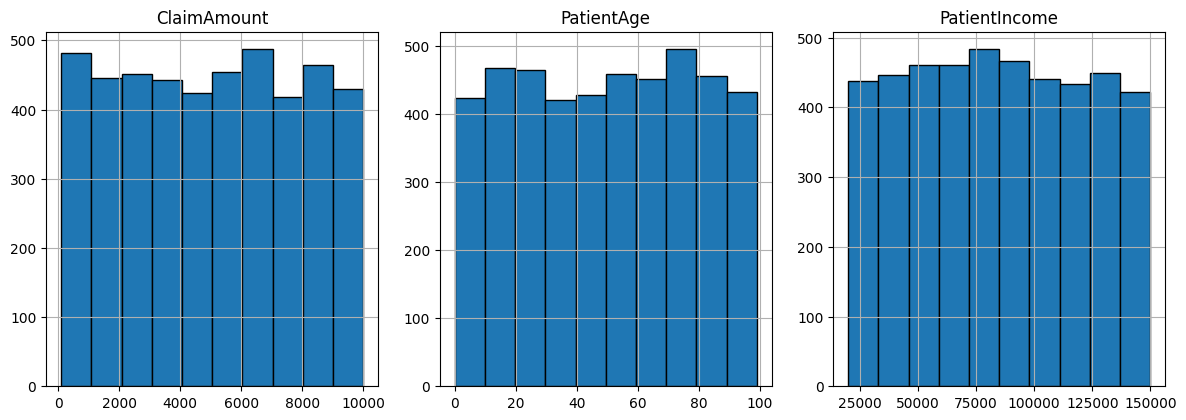

In [12]:
df.hist(figsize=(12, 8), layout=(2, 3), edgecolor='black')
plt.tight_layout()
plt.show()

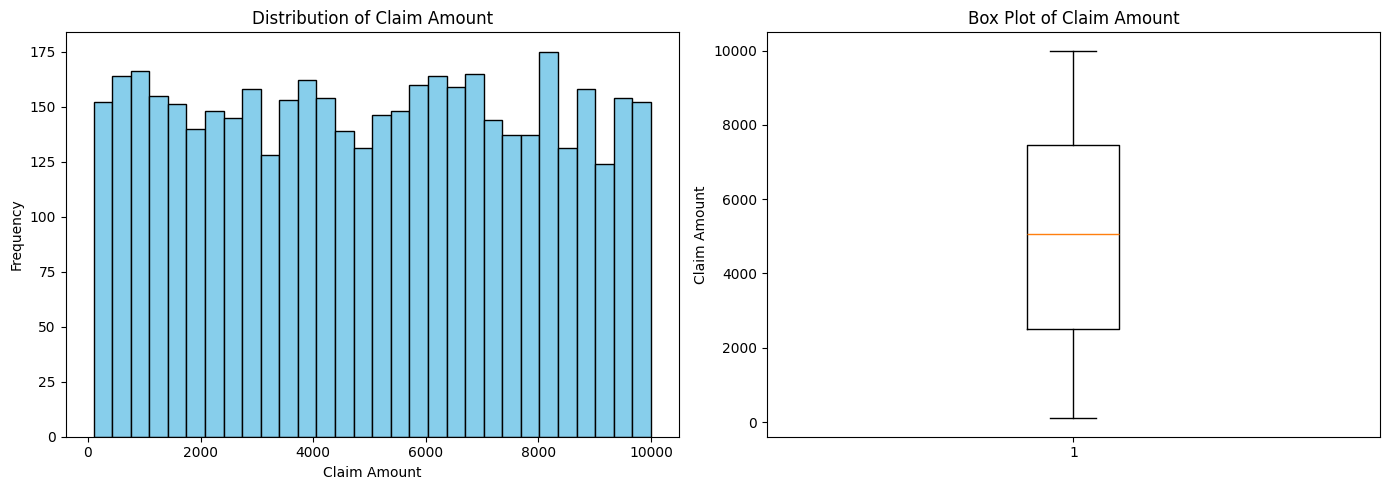

In [13]:
# Univariate Analysis - ClaimAmount
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribution of ClaimAmount
axes[0].hist(df['ClaimAmount'], bins=30, edgecolor='black', color='skyblue')
axes[0].set_xlabel('Claim Amount')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribution of Claim Amount')

# Box plot of ClaimAmount
axes[1].boxplot(df['ClaimAmount'])
axes[1].set_ylabel('Claim Amount')
axes[1].set_title('Box Plot of Claim Amount')

plt.tight_layout()
plt.show()


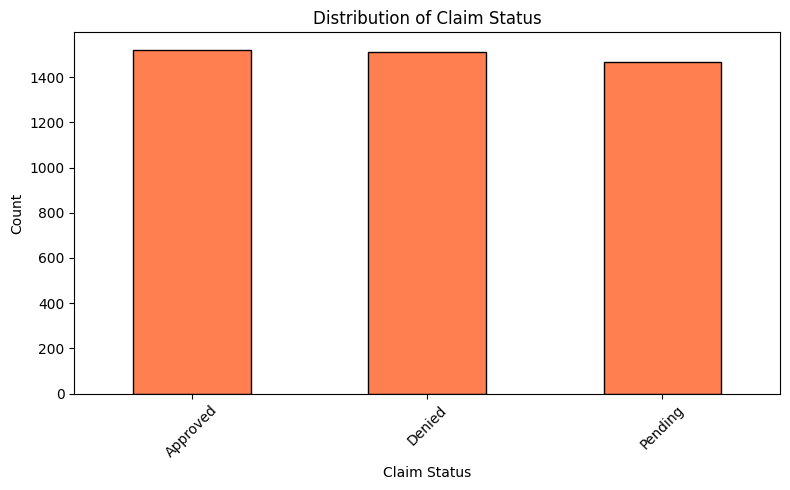

In [14]:
# Univariate Analysis - ClaimStatus
fig, ax = plt.subplots(figsize=(8, 5))
df['ClaimStatus'].value_counts().plot(kind='bar', ax=ax, color='coral', edgecolor='black')
ax.set_xlabel('Claim Status')
ax.set_ylabel('Count')
ax.set_title('Distribution of Claim Status')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()


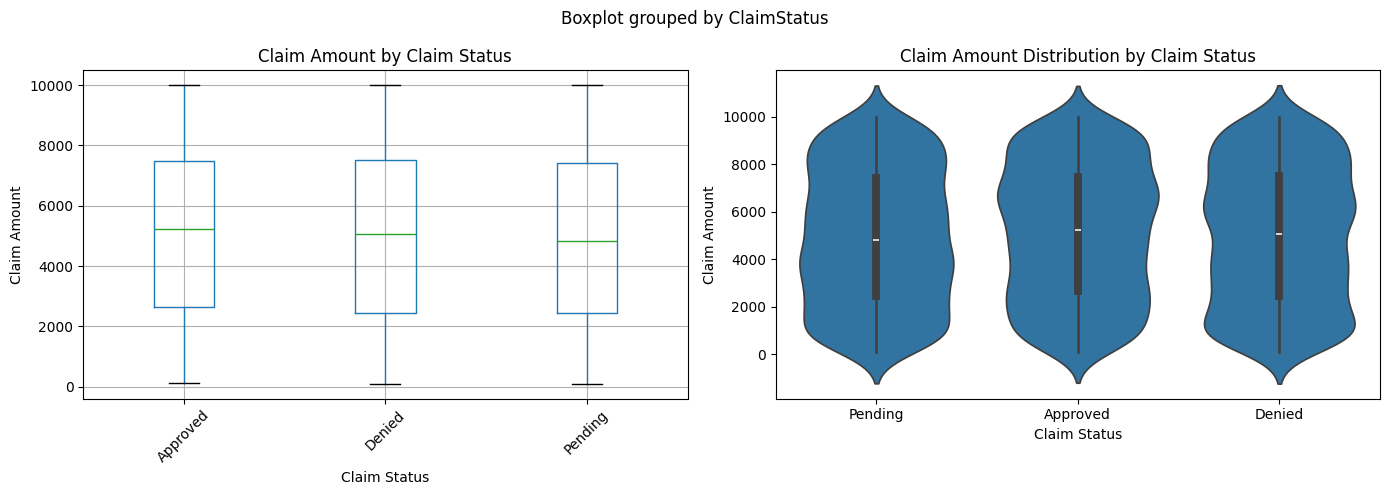

In [15]:
# Bivariate Analysis - ClaimAmount vs ClaimStatus
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Box plot
df.boxplot(column='ClaimAmount', by='ClaimStatus', ax=axes[0])
axes[0].set_xlabel('Claim Status')
axes[0].set_ylabel('Claim Amount')
axes[0].set_title('Claim Amount by Claim Status')
plt.sca(axes[0])
plt.xticks(rotation=45)

# Violin plot
sns.violinplot(data=df, x='ClaimStatus', y='ClaimAmount', ax=axes[1])
axes[1].set_xlabel('Claim Status')
axes[1].set_ylabel('Claim Amount')
axes[1].set_title('Claim Amount Distribution by Claim Status')

plt.tight_layout()
plt.show()


In [16]:

# Summary statistics by ClaimStatus
print(df.groupby('ClaimStatus')['ClaimAmount'].describe())

              count         mean          std     min        25%       50%  \
ClaimStatus                                                                  
Approved     1522.0  5123.594054  2836.187981  106.47  2655.2300  5228.045   
Denied       1512.0  4993.977632  2902.434477  100.12  2450.4725  5070.570   
Pending      1466.0  4921.495955  2858.069545  100.30  2453.1725  4831.925   

                   75%      max  
ClaimStatus                      
Approved     7489.1550  9997.20  
Denied       7508.7925  9994.20  
Pending      7405.6275  9995.62  


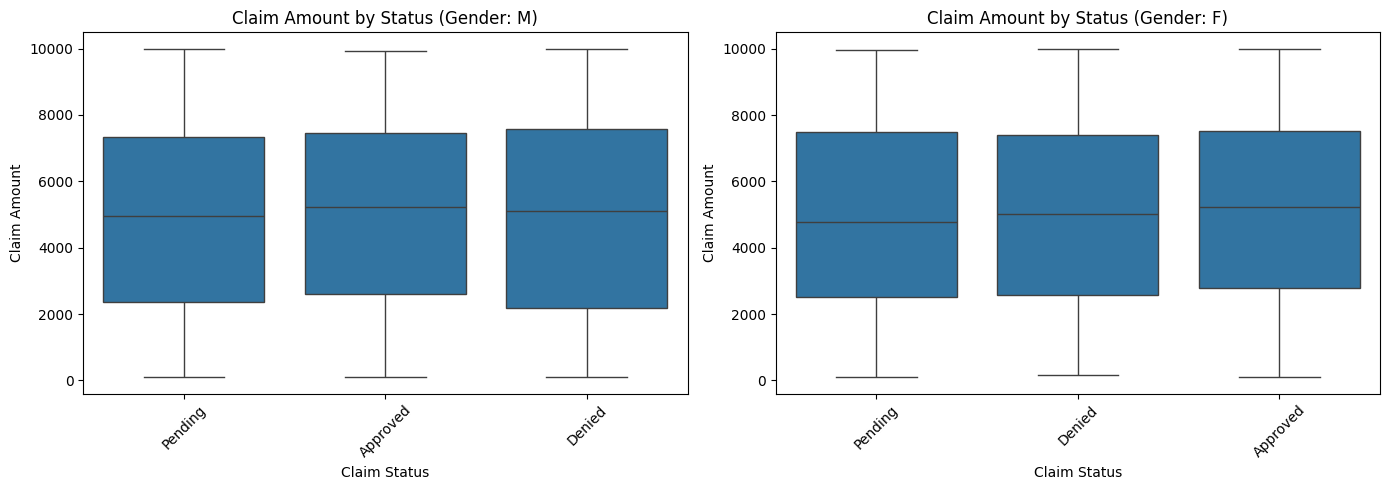

In [17]:
# Multivariate Analysis - ClaimAmount and ClaimStatus with other variables

# 1. ClaimAmount vs ClaimStatus by PatientGender
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for idx, gender in enumerate(df['PatientGender'].unique()):
    sns.boxplot(data=df[df['PatientGender'] == gender], x='ClaimStatus', y='ClaimAmount', ax=axes[idx])
    axes[idx].set_title(f'Claim Amount by Status (Gender: {gender})')
    axes[idx].set_xlabel('Claim Status')
    axes[idx].set_ylabel('Claim Amount')
    plt.sca(axes[idx])
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


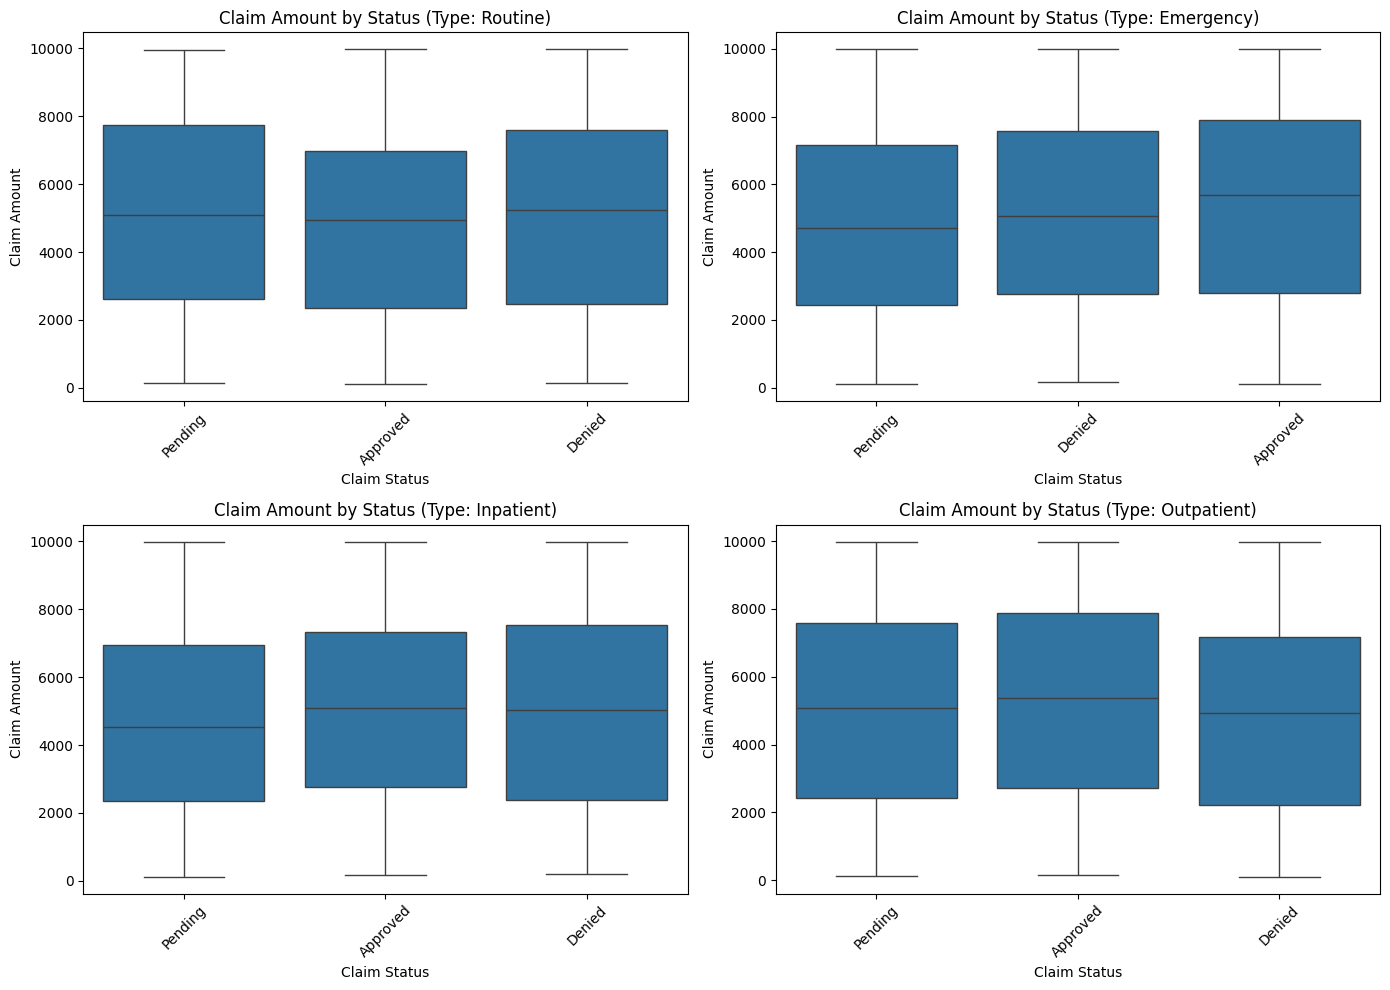

In [18]:
# 2. ClaimAmount vs ClaimStatus by ClaimType
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.ravel()

for idx, claim_type in enumerate(df['ClaimType'].unique()):
    sns.boxplot(data=df[df['ClaimType'] == claim_type], x='ClaimStatus', y='ClaimAmount', ax=axes[idx])
    axes[idx].set_title(f'Claim Amount by Status (Type: {claim_type})')
    axes[idx].set_xlabel('Claim Status')
    axes[idx].set_ylabel('Claim Amount')
    plt.sca(axes[idx])
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


In [19]:
# 3. Pivot table analysis
pivot_table = df.pivot_table(values='ClaimAmount', index='ClaimStatus', columns='ClaimType', aggfunc='mean')
print("Average Claim Amount by Status and Type:")
print(pivot_table)


Average Claim Amount by Status and Type:
ClaimType      Emergency    Inpatient   Outpatient      Routine
ClaimStatus                                                    
Approved     5291.625226  5059.365323  5306.962146  4845.047870
Denied       5089.697962  4972.593713  4886.530876  5031.070465
Pending      4786.368109  4766.795726  4976.218886  5145.819735


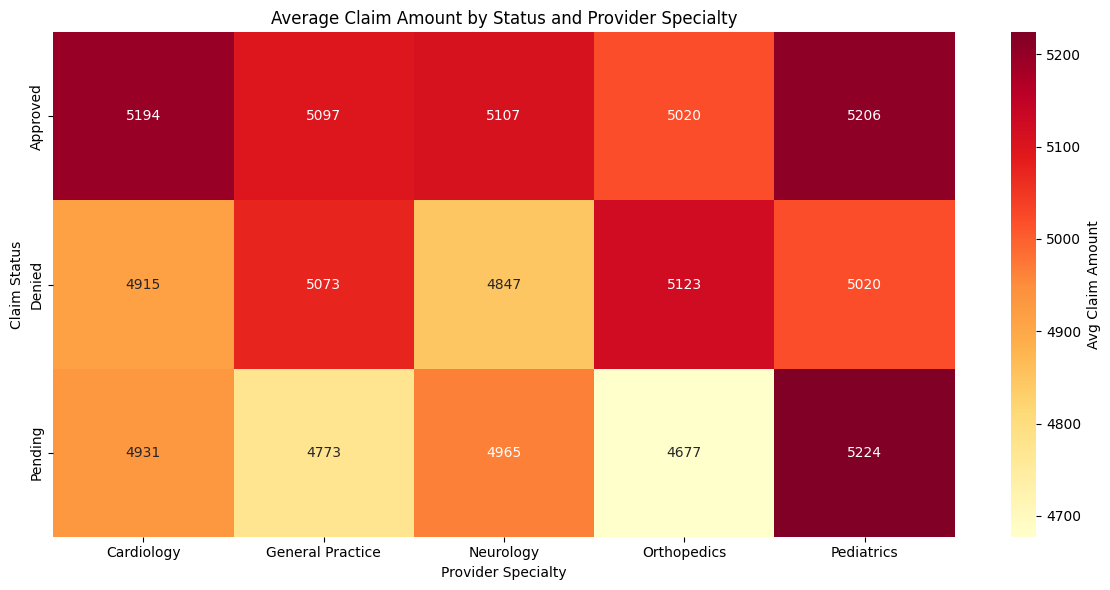

In [20]:
# 4. Heatmap of ClaimAmount by ClaimStatus and ProviderSpecialty
pivot_specialty = df.pivot_table(values='ClaimAmount', index='ClaimStatus', columns='ProviderSpecialty', aggfunc='mean')
plt.figure(figsize=(12, 6))
sns.heatmap(pivot_specialty, annot=True, fmt='.0f', cmap='YlOrRd', cbar_kws={'label': 'Avg Claim Amount'})
plt.title('Average Claim Amount by Status and Provider Specialty')
plt.xlabel('Provider Specialty')
plt.ylabel('Claim Status')
plt.tight_layout()
plt.show()


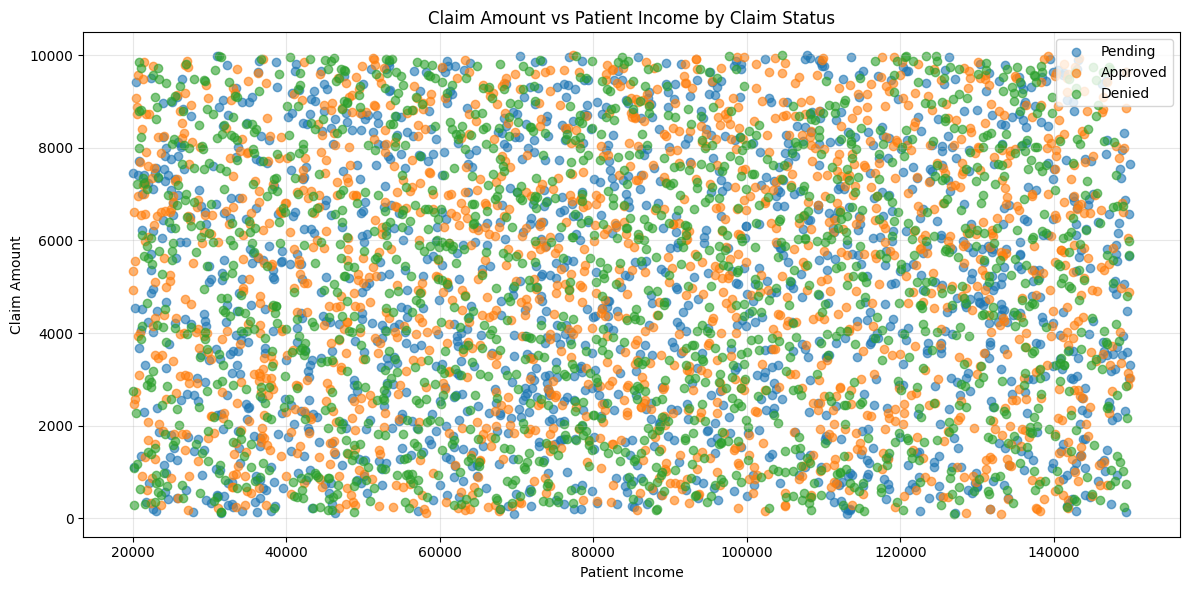

In [21]:
# 5. Scatter plot: ClaimAmount vs PatientIncome colored by ClaimStatus
plt.figure(figsize=(12, 6))
for status in df['ClaimStatus'].unique():
    subset = df[df['ClaimStatus'] == status]
    plt.scatter(subset['PatientIncome'], subset['ClaimAmount'], label=status, alpha=0.6)

plt.xlabel('Patient Income')
plt.ylabel('Claim Amount')
plt.title('Claim Amount vs Patient Income by Claim Status')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [22]:
# 6. Groupby analysis
print("\nMultivariate Summary Statistics:")
print(df.groupby(['ClaimStatus', 'ClaimType'])['ClaimAmount'].describe())


Multivariate Summary Statistics:
                        count         mean          std     min        25%  \
ClaimStatus ClaimType                                                        
Approved    Emergency   354.0  5291.625226  2882.505985  111.01  2782.8725   
            Inpatient   387.0  5059.365323  2790.242075  174.87  2757.9500   
            Outpatient  396.0  5306.962146  2871.733897  163.22  2729.1825   
            Routine     385.0  4845.047870  2787.797032  106.47  2365.8700   
Denied      Emergency   368.0  5089.697962  2861.371169  157.01  2762.2500   
            Inpatient   369.0  4972.593713  2917.725169  192.38  2377.0900   
            Outpatient  388.0  4886.530876  2926.324783  100.12  2215.6100   
            Routine     387.0  5031.070465  2909.985739  141.46  2470.8300   
Pending     Emergency   349.0  4786.368109  2828.412720  100.30  2450.5900   
            Inpatient   372.0  4766.795726  2815.667641  119.72  2354.6900   
            Outpatient  368.0 

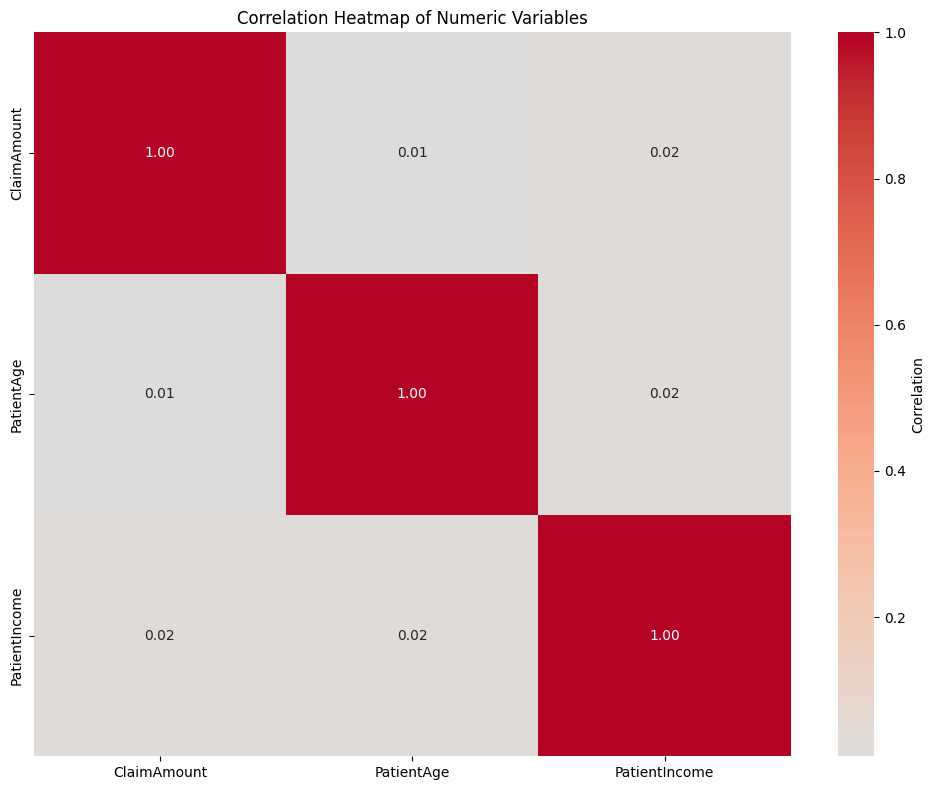

In [23]:
# 7. Correlation heatmap for numeric columns
plt.figure(figsize=(10, 8))
numeric_cols = df.select_dtypes(include=[np.number]).columns
sns.heatmap(df[numeric_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0, cbar_kws={'label': 'Correlation'})
plt.title('Correlation Heatmap of Numeric Variables')
plt.tight_layout()
plt.show()


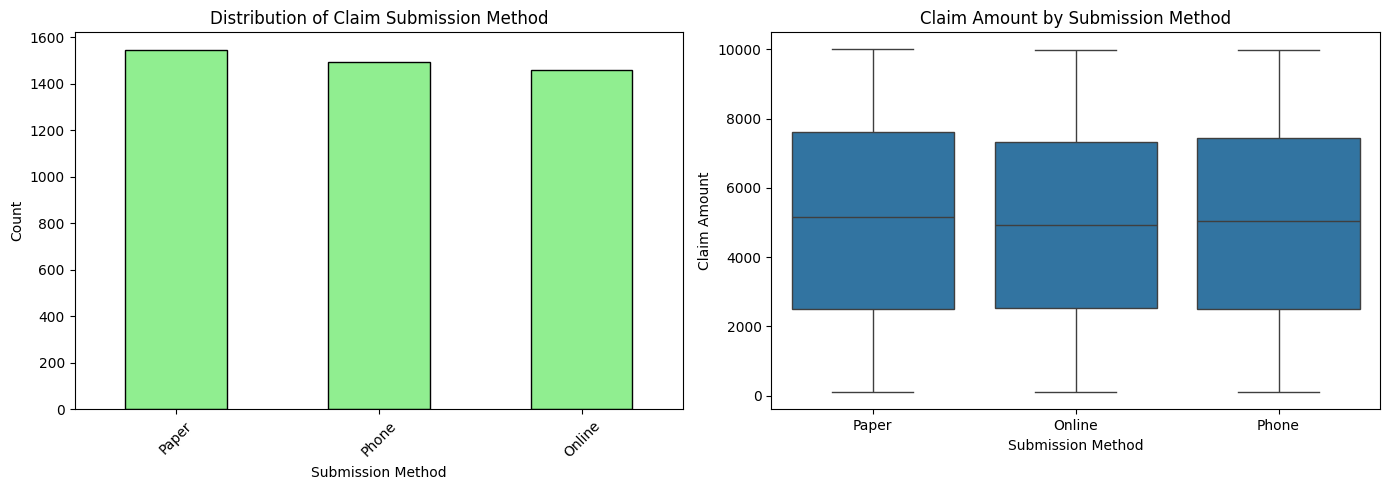

In [24]:
# 8. Distribution by ClaimSubmissionMethod
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df['ClaimSubmissionMethod'].value_counts().plot(kind='bar', ax=axes[0], color='lightgreen', edgecolor='black')
axes[0].set_title('Distribution of Claim Submission Method')
axes[0].set_xlabel('Submission Method')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=45)

sns.boxplot(data=df, x='ClaimSubmissionMethod', y='ClaimAmount', ax=axes[1])
axes[1].set_title('Claim Amount by Submission Method')
axes[1].set_xlabel('Submission Method')
axes[1].set_ylabel('Claim Amount')

plt.tight_layout()
plt.show()


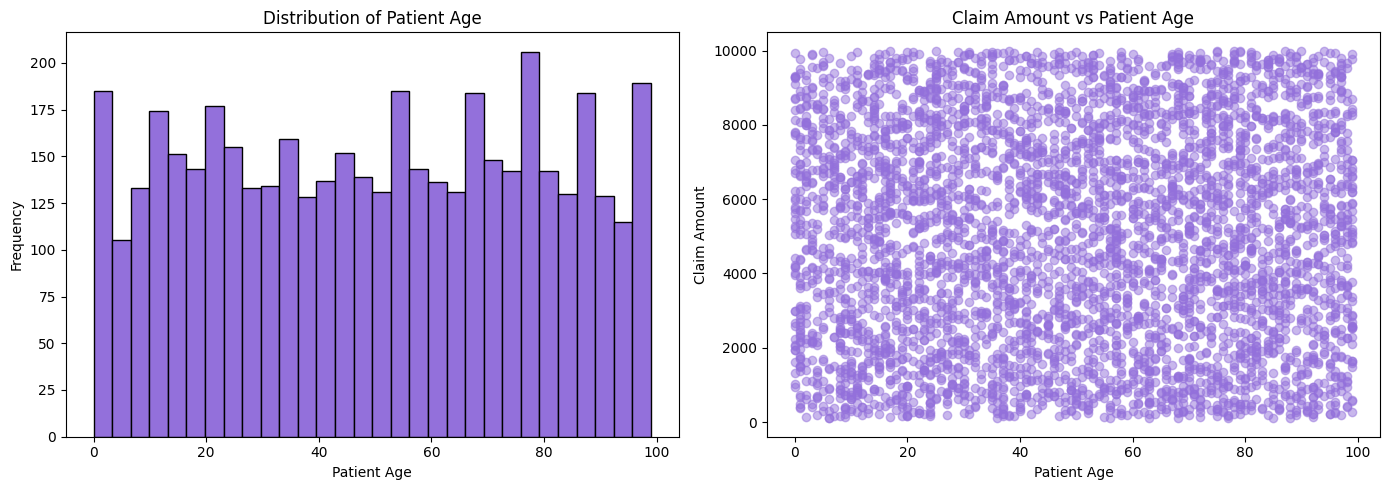

In [25]:

# 9. PatientAge distribution and relationship with ClaimAmount
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['PatientAge'], bins=30, edgecolor='black', color='mediumpurple')
axes[0].set_xlabel('Patient Age')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribution of Patient Age')

axes[1].scatter(df['PatientAge'], df['ClaimAmount'], alpha=0.5, color='mediumpurple')
axes[1].set_xlabel('Patient Age')
axes[1].set_ylabel('Claim Amount')
axes[1].set_title('Claim Amount vs Patient Age')

plt.tight_layout()
plt.show()


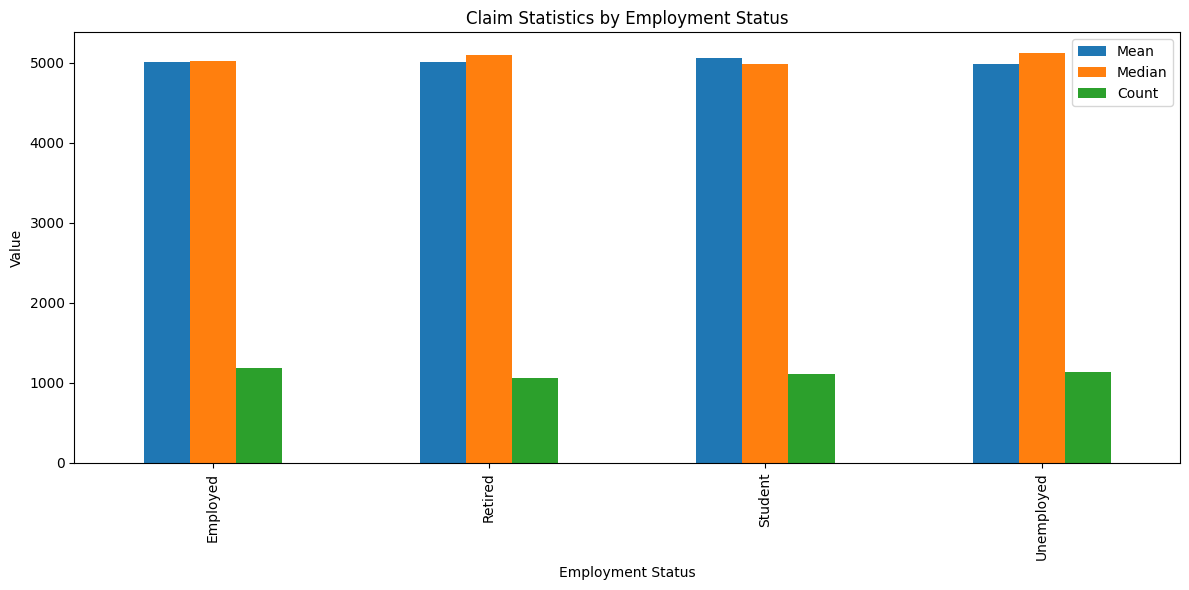

In [26]:
# 10. Employment Status impact on Claims
plt.figure(figsize=(12, 6))
employment_claim = df.groupby('PatientEmploymentStatus')['ClaimAmount'].agg(['mean', 'median', 'count'])
employment_claim.plot(kind='bar', ax=plt.gca())
plt.title('Claim Statistics by Employment Status')
plt.xlabel('Employment Status')
plt.ylabel('Value')
plt.legend(['Mean', 'Median', 'Count'])
plt.tight_layout()
plt.show()

In [27]:
# Feature Engineering for Claim Prediction

# 1. Create age groups
df['AgeGroup'] = pd.cut(df['PatientAge'], bins=[0, 18, 35, 50, 65, 100], 
                         labels=['Child', 'Young Adult', 'Middle Aged', 'Senior', 'Elderly'])

# 2. Create income groups
df['IncomeGroup'] = pd.qcut(df['PatientIncome'], q=4, 
                             labels=['Low', 'Medium', 'High', 'Very High'])

# 3. Create claim size category
df['ClaimSizeCategory'] = pd.cut(df['ClaimAmount'], 
                                  bins=[0, 2500, 5000, 7500, 15000],
                                  labels=['Small', 'Medium', 'Large', 'Very Large'])

# 4. Claim approval rate by provider specialty
approval_rates = df.groupby('ProviderSpecialty')['ClaimStatus'].apply(
    lambda x: (x == 'Approved').sum() / len(x)
).to_dict()
df['SpecialtyApprovalRate'] = df['ProviderSpecialty'].map(approval_rates)

# 5. Claim approval rate by submission method
submission_approval = df.groupby('ClaimSubmissionMethod')['ClaimStatus'].apply(
    lambda x: (x == 'Approved').sum() / len(x)
).to_dict()
df['SubmissionMethodApprovalRate'] = df['ClaimSubmissionMethod'].map(submission_approval)

# 6. Patient risk score (based on employment status and claim history)
employment_avg_claim = df.groupby('PatientEmploymentStatus')['ClaimAmount'].mean().to_dict()
df['EmploymentRiskScore'] = df['PatientEmploymentStatus'].map(employment_avg_claim)

# 7. Interaction features
df['AgeIncomeRatio'] = df['PatientAge'] / (df['PatientIncome'] + 1)
df['ClaimAmountPerAge'] = df['ClaimAmount'] / (df['PatientAge'] + 1)

# 8. Encode ClaimStatus for prediction (1 = Approved, 0 = Denied/Pending)
df['IsApproved'] = (df['ClaimStatus'] == 'Approved').astype(int)


df.head()

,ClaimAmount,ClaimDate,DiagnosisCode,ProcedureCode,PatientAge,PatientGender,ProviderSpecialty,ClaimStatus,PatientIncome,PatientMaritalStatus,...,ClaimSubmissionMethod,AgeGroup,IncomeGroup,ClaimSizeCategory,SpecialtyApprovalRate,SubmissionMethodApprovalRate,EmploymentRiskScore,AgeIncomeRatio,ClaimAmountPerAge,IsApproved
0,3807.95,2024-06-07,yy006,hd662,16,M,Cardiology,Pending,90279.43,Married,...,Paper,Child,High,Medium,0.342889,0.339378,5003.195024,0.000177,223.997059,0
1,9512.07,2023-05-30,tD052,mH831,27,M,Pediatrics,Approved,130448.02,Single,...,Online,Young Adult,Very High,Very Large,0.313089,0.328542,5060.289532,0.000207,339.716786,1
2,7346.74,2022-09-27,zx832,dg637,40,F,Cardiology,Pending,82417.54,Divorced,...,Online,Middle Aged,Medium,Large,0.342889,0.328542,5008.918973,0.000485,179.188780,0
3,6026.72,2023-06-25,kr421,kG326,65,M,Neurology,Pending,68516.96,Widowed,...,Phone,Senior,Medium,Large,0.354913,0.346488,5060.289532,0.000949,91.313939,0
4,1644.58,2023-07-24,LZ261,cx805,24,M,General Practice,Pending,84122.17,Married,...,Phone,Young Adult,High,Small,0.318182,0.346488,5060.289532,0.000285,65.783200,0


In [28]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4500 entries, 0 to 4499
Data columns (total 23 columns):
 #   Column                        Non-Null Count  Dtype   
---  ------                        --------------  -----   
 0   ClaimAmount                   4500 non-null   float64 
 1   ClaimDate                     4500 non-null   object  
 2   DiagnosisCode                 4500 non-null   object  
 3   ProcedureCode                 4500 non-null   object  
 4   PatientAge                    4500 non-null   int64   
 5   PatientGender                 4500 non-null   object  
 6   ProviderSpecialty             4500 non-null   object  
 7   ClaimStatus                   4500 non-null   object  
 8   PatientIncome                 4500 non-null   float64 
 9   PatientMaritalStatus          4500 non-null   object  
 10  PatientEmploymentStatus       4500 non-null   object  
 11  ProviderLocation              4500 non-null   object  
 12  ClaimType                     4500 non-null   ob

In [29]:
df['ClaimDate'] = pd.to_datetime(df['ClaimDate'])

# Extract temporal features
df['ClaimYear'] = df['ClaimDate'].dt.year
df['ClaimMonth'] = df['ClaimDate'].dt.month
df['ClaimDayOfWeek'] = df['ClaimDate'].dt.dayofweek
df['ClaimQuarter'] = df['ClaimDate'].dt.quarter
df['ClaimDayOfYear'] = df['ClaimDate'].dt.dayofyear

# Create cyclical features for month (seasonal patterns)
df['ClaimMonth_sin'] = np.sin(2 * np.pi * df['ClaimMonth'] / 12)
df['ClaimMonth_cos'] = np.cos(2 * np.pi * df['ClaimMonth'] / 12)

# Create cyclical features for day of week
df['ClaimDayOfWeek_sin'] = np.sin(2 * np.pi * df['ClaimDayOfWeek'] / 7)
df['ClaimDayOfWeek_cos'] = np.cos(2 * np.pi * df['ClaimDayOfWeek'] / 7)

# Create binary features for weekend/weekday
df['IsWeekend'] = (df['ClaimDayOfWeek'] >= 5).astype(int)

# Create binary features for quarters
df['IsQ1'] = (df['ClaimQuarter'] == 1).astype(int)
df['IsQ2'] = (df['ClaimQuarter'] == 2).astype(int)
df['IsQ3'] = (df['ClaimQuarter'] == 3).astype(int)
df['IsQ4'] = (df['ClaimQuarter'] == 4).astype(int)

df.head()

,ClaimAmount,ClaimDate,DiagnosisCode,ProcedureCode,PatientAge,PatientGender,ProviderSpecialty,ClaimStatus,PatientIncome,PatientMaritalStatus,...,ClaimDayOfYear,ClaimMonth_sin,ClaimMonth_cos,ClaimDayOfWeek_sin,ClaimDayOfWeek_cos,IsWeekend,IsQ1,IsQ2,IsQ3,IsQ4
0,3807.95,2024-06-07,yy006,hd662,16,M,Cardiology,Pending,90279.43,Married,...,159,1.224647e-16,-1.000000e+00,-0.433884,-0.900969,0,0,1,0,0
1,9512.07,2023-05-30,tD052,mH831,27,M,Pediatrics,Approved,130448.02,Single,...,150,5.000000e-01,-8.660254e-01,0.781831,0.623490,0,0,1,0,0
2,7346.74,2022-09-27,zx832,dg637,40,F,Cardiology,Pending,82417.54,Divorced,...,270,-1.000000e+00,-1.836970e-16,0.781831,0.623490,0,0,0,1,0
3,6026.72,2023-06-25,kr421,kG326,65,M,Neurology,Pending,68516.96,Widowed,...,176,1.224647e-16,-1.000000e+00,-0.781831,0.623490,1,0,1,0,0
4,1644.58,2023-07-24,LZ261,cx805,24,M,General Practice,Pending,84122.17,Married,...,205,-5.000000e-01,-8.660254e-01,0.000000,1.000000,0,0,0,1,0


In [30]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4500 entries, 0 to 4499
Data columns (total 37 columns):
 #   Column                        Non-Null Count  Dtype         
---  ------                        --------------  -----         
 0   ClaimAmount                   4500 non-null   float64       
 1   ClaimDate                     4500 non-null   datetime64[ns]
 2   DiagnosisCode                 4500 non-null   object        
 3   ProcedureCode                 4500 non-null   object        
 4   PatientAge                    4500 non-null   int64         
 5   PatientGender                 4500 non-null   object        
 6   ProviderSpecialty             4500 non-null   object        
 7   ClaimStatus                   4500 non-null   object        
 8   PatientIncome                 4500 non-null   float64       
 9   PatientMaritalStatus          4500 non-null   object        
 10  PatientEmploymentStatus       4500 non-null   object        
 11  ProviderLocation              

In [31]:
df.columns  

Index(['ClaimAmount', 'ClaimDate', 'DiagnosisCode', 'ProcedureCode',
       'PatientAge', 'PatientGender', 'ProviderSpecialty', 'ClaimStatus',
       'PatientIncome', 'PatientMaritalStatus', 'PatientEmploymentStatus',
       'ProviderLocation', 'ClaimType', 'ClaimSubmissionMethod', 'AgeGroup',
       'IncomeGroup', 'ClaimSizeCategory', 'SpecialtyApprovalRate',
       'SubmissionMethodApprovalRate', 'EmploymentRiskScore', 'AgeIncomeRatio',
       'ClaimAmountPerAge', 'IsApproved', 'ClaimYear', 'ClaimMonth',
       'ClaimDayOfWeek', 'ClaimQuarter', 'ClaimDayOfYear', 'ClaimMonth_sin',
       'ClaimMonth_cos', 'ClaimDayOfWeek_sin', 'ClaimDayOfWeek_cos',
       'IsWeekend', 'IsQ1', 'IsQ2', 'IsQ3', 'IsQ4'],
      dtype='object')

In [32]:
import pandas as pd
from sklearn.preprocessing import StandardScaler



# List of numeric columns to standardize
numeric_cols = [
    'ClaimAmount', 'PatientAge', 'PatientIncome',
    'SpecialtyApprovalRate', 'SubmissionMethodApprovalRate',
    'EmploymentRiskScore', 'AgeIncomeRatio', 'ClaimAmountPerAge',
    'ClaimYear', 'ClaimMonth_sin', 'ClaimMonth_cos',
    'ClaimDayOfWeek_sin', 'ClaimDayOfWeek_cos'
]

# Initialize the scaler
scaler = StandardScaler()

# Fit & transform the numeric columns
df_scaled = scaler.fit_transform(df[numeric_cols])

# Create a new dataframe with scaled values
df[numeric_cols] = df_scaled

df.head()


,ClaimAmount,ClaimDate,DiagnosisCode,ProcedureCode,PatientAge,PatientGender,ProviderSpecialty,ClaimStatus,PatientIncome,PatientMaritalStatus,...,ClaimDayOfYear,ClaimMonth_sin,ClaimMonth_cos,ClaimDayOfWeek_sin,ClaimDayOfWeek_cos,IsWeekend,IsQ1,IsQ2,IsQ3,IsQ4
0,-0.420888,2024-06-07,yy006,hd662,-1.175465,M,Cardiology,Pending,0.158977,Married,...,159,0.020644,-1.420905,-0.598786,-1.285283,0,0,1,0,0
1,1.569403,2023-05-30,tD052,mH831,-0.793352,M,Pediatrics,Approved,1.242220,Single,...,150,0.730033,-1.231991,1.122263,0.868833,0,0,1,0,0
2,0.813872,2022-09-27,zx832,dg637,-0.341764,F,Cardiology,Pending,-0.053038,Divorced,...,270,-1.398133,-0.010832,1.122263,0.868833,0,0,0,1,0
3,0.353289,2023-06-25,kr421,kG326,0.526676,M,Neurology,Pending,-0.427901,Widowed,...,176,0.020644,-1.420905,-1.091364,0.868833,1,0,1,0,0
4,-1.175735,2023-07-24,LZ261,cx805,-0.897565,M,General Practice,Pending,-0.007069,Married,...,205,-0.688745,-1.231991,0.015450,1.400856,0,0,0,1,0


In [33]:
df.columns

Index(['ClaimAmount', 'ClaimDate', 'DiagnosisCode', 'ProcedureCode',
       'PatientAge', 'PatientGender', 'ProviderSpecialty', 'ClaimStatus',
       'PatientIncome', 'PatientMaritalStatus', 'PatientEmploymentStatus',
       'ProviderLocation', 'ClaimType', 'ClaimSubmissionMethod', 'AgeGroup',
       'IncomeGroup', 'ClaimSizeCategory', 'SpecialtyApprovalRate',
       'SubmissionMethodApprovalRate', 'EmploymentRiskScore', 'AgeIncomeRatio',
       'ClaimAmountPerAge', 'IsApproved', 'ClaimYear', 'ClaimMonth',
       'ClaimDayOfWeek', 'ClaimQuarter', 'ClaimDayOfYear', 'ClaimMonth_sin',
       'ClaimMonth_cos', 'ClaimDayOfWeek_sin', 'ClaimDayOfWeek_cos',
       'IsWeekend', 'IsQ1', 'IsQ2', 'IsQ3', 'IsQ4'],
      dtype='object')

In [34]:
import pandas as pd

# categorical columns to encode
categorical_cols = [
    'PatientGender', 'ProviderSpecialty', 'PatientMaritalStatus',
    'PatientEmploymentStatus', 'ProviderLocation', 'ClaimType',
    'ClaimSubmissionMethod', 'AgeGroup', 'IncomeGroup', 'ClaimSizeCategory'
]

# One-hot encode
df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)  # drop_first avoids dummy variable trap
df.head()


,ClaimAmount,ClaimDate,DiagnosisCode,ProcedureCode,PatientAge,ClaimStatus,PatientIncome,SpecialtyApprovalRate,SubmissionMethodApprovalRate,EmploymentRiskScore,...,AgeGroup_Young Adult,AgeGroup_Middle Aged,AgeGroup_Senior,AgeGroup_Elderly,IncomeGroup_Medium,IncomeGroup_High,IncomeGroup_Very High,ClaimSizeCategory_Medium,ClaimSizeCategory_Large,ClaimSizeCategory_Very Large
0,-0.420888,2024-06-07,yy006,hd662,-1.175465,Pending,0.158977,0.232796,0.157927,-0.395586,...,False,False,False,False,False,True,False,True,False,False
1,1.569403,2023-05-30,tD052,mH831,-0.793352,Approved,1.242220,-1.253834,-1.322434,1.656017,...,True,False,False,False,False,False,True,False,False,True
2,0.813872,2022-09-27,zx832,dg637,-0.341764,Pending,-0.053038,0.232796,-1.322434,-0.189904,...,False,True,False,False,True,False,False,False,True,False
3,0.353289,2023-06-25,kr421,kG326,0.526676,Pending,-0.427901,0.832677,1.129255,1.656017,...,False,False,True,False,True,False,False,False,True,False
4,-1.175735,2023-07-24,LZ261,cx805,-0.897565,Pending,-0.007069,-0.999767,1.129255,1.656017,...,True,False,False,False,False,True,False,False,False,False


In [35]:
df.columns

Index(['ClaimAmount', 'ClaimDate', 'DiagnosisCode', 'ProcedureCode',
       'PatientAge', 'ClaimStatus', 'PatientIncome', 'SpecialtyApprovalRate',
       'SubmissionMethodApprovalRate', 'EmploymentRiskScore',
       ...
       'AgeGroup_Young Adult', 'AgeGroup_Middle Aged', 'AgeGroup_Senior',
       'AgeGroup_Elderly', 'IncomeGroup_Medium', 'IncomeGroup_High',
       'IncomeGroup_Very High', 'ClaimSizeCategory_Medium',
       'ClaimSizeCategory_Large', 'ClaimSizeCategory_Very Large'],
      dtype='object', length=3928)

In [36]:
from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# Prepare features and target
X = df.drop(columns=['ClaimStatus','ClaimAmount', 'ClaimDate', 'DiagnosisCode', 'ProcedureCode'])
y = df['ClaimAmount']

# Train-test split (80-20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and train XGBoost model
xgb_model = XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=6, random_state=42)
xgb_model.fit(X_train, y_train)

# Make predictions
y_pred_train = xgb_model.predict(X_train)
y_pred_test = xgb_model.predict(X_test)

In [37]:
# Calculate metrics
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

train_r2 = r2_score(y_train, y_pred_train)
train_rmse = np.sqrt(mean_squared_error(y_train, y_pred_train))
train_mae = mean_absolute_error(y_train, y_pred_train)

test_r2 = r2_score(y_test, y_pred_test)
test_rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))
test_mae = mean_absolute_error(y_test, y_pred_test)

# Evaluate the model results
print("=" * 60)
print("XGBoost Model Performance Evaluation")
print("=" * 60)

print("\n--- Training Set Metrics ---")
print(f"R² Score (Train):  {train_r2:.4f}")
print(f"RMSE (Train):      {train_rmse:.4f}")
print(f"MAE (Train):       {train_mae:.4f}")

print("\n--- Test Set Metrics ---")
print(f"R² Score (Test):   {test_r2:.4f}")
print(f"RMSE (Test):       {test_rmse:.4f}")
print(f"MAE (Test):        {test_mae:.4f}")

print("\n--- Model Interpretation ---")
print(f"• The model explains {test_r2*100:.2f}% of variance in test data")
print(f"• Average prediction error (MAE): {test_mae:.4f} standard deviations")
print(f"• Root mean squared error (RMSE): {test_rmse:.4f} standard deviations")

# Check for overfitting
train_test_gap = train_r2 - test_r2
print(f"\n--- Overfitting Check ---")
print(f"Train-Test R² Gap: {train_test_gap:.4f}")
if train_test_gap < 0.01:
    print("✓ Excellent generalization - minimal overfitting")
elif train_test_gap < 0.05:
    print("✓ Good generalization - slight overfitting")
else:
    print("⚠ Moderate overfitting detected")

# Feature importance
print("\n--- Top 10 Most Important Features ---")
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': xgb_model.feature_importances_
}).sort_values('Importance', ascending=False)

print(feature_importance.head(10).to_string(index=False))

XGBoost Model Performance Evaluation

--- Training Set Metrics ---
R² Score (Train):  0.9938
RMSE (Train):      0.0791
MAE (Train):       0.0552

--- Test Set Metrics ---
R² Score (Test):   0.9872
RMSE (Test):       0.1119
MAE (Test):        0.0750

--- Model Interpretation ---
• The model explains 98.72% of variance in test data
• Average prediction error (MAE): 0.0750 standard deviations
• Root mean squared error (RMSE): 0.1119 standard deviations

--- Overfitting Check ---
Train-Test R² Gap: 0.0066
✓ Excellent generalization - minimal overfitting

--- Top 10 Most Important Features ---
                              Feature  Importance
         ClaimSizeCategory_Very Large    0.587756
              ClaimSizeCategory_Large    0.303682
             ClaimSizeCategory_Medium    0.059096
                    ClaimAmountPerAge    0.002385
                 AgeGroup_Young Adult    0.001769
                           PatientAge    0.001490
                       AgeIncomeRatio    0.000941
Prov

In [38]:
import joblib

# Save the trained XGBoost model
joblib.dump(xgb_model, 'xgb_model.pkl')

print("Model saved successfully as 'xgb_model.pkl'")

Model saved successfully as 'xgb_model.pkl'


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score
import xgboost as xgb
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Check class distribution
print("Class Distribution:")
print(df['ClaimStatus'].value_counts())
print("\nClass Proportions:")
print(df['ClaimStatus'].value_counts(normalize=True))

# Encode target
le_target = LabelEncoder()
df['ClaimStatus_encoded'] = le_target.fit_transform(df['ClaimStatus'])
class_names = le_target.classes_

y = df['ClaimStatus_encoded']

# Prepare features
X = df.drop(columns=[
    'ClaimStatus', 
    'ClaimStatus_encoded',
    "ClaimDate",
    'IsApproved'
])

# Encode categorical columns
cat_cols = X.select_dtypes(include=['object']).columns
for col in cat_cols:
    enc = LabelEncoder()
    X[col] = enc.fit_transform(X[col].astype(str))

# Train-test split with stratification
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nTraining set size: {X_train.shape}")
print(f"Test set size: {X_test.shape}")

# Calculate class weights to handle imbalance
from sklearn.utils.class_weight import compute_class_weight
class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
scale_pos_weight_dict = {i: class_weights[i] for i in range(len(class_weights))}
print(f"\nClass Weights: {scale_pos_weight_dict}")

# Hyperparameter tuning with GridSearchCV
param_grid = {
    'n_estimators': [300, 500],
    'max_depth': [5, 7, 9],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.7, 0.8, 0.9],
    'colsample_bytree': [0.7, 0.8, 0.9],
    'min_child_weight': [1, 3, 5],
    'gamma': [0, 0.1, 0.5]
}

# Use smaller grid for faster tuning
param_grid_reduced = {
    'n_estimators': [300, 500],
    'max_depth': [6, 8],
    'learning_rate': [0.05, 0.1],
    'subsample': [0.8, 0.9],
    'colsample_bytree': [0.8, 0.9]
}

xgb_base = xgb.XGBClassifier(
    objective='multi:softmax',
    num_class=len(class_names),
    eval_metric='mlogloss',
    random_state=42,
    n_jobs=-1,
    tree_method='hist',
    scale_pos_weight=1
)

# GridSearchCV
grid_search = GridSearchCV(
    xgb_base,
    param_grid_reduced,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=2
)

grid_search.fit(X_train, y_train)

print(f"\nBest parameters: {grid_search.best_params_}")
print(f"Best CV score: {grid_search.best_score_:.4f}")

# Train final model with best parameters
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)

# Evaluation
print("\n" + "="*70)
print("TUNED XGBOOST MULTICLASS CLASSIFICATION PERFORMANCE")
print("="*70)
print(f"Test Accuracy: {accuracy_score(y_test, y_pred):.4f}")

print("\n--- Classification Report ---")
print(classification_report(y_test, y_pred, target_names=class_names))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Tuned XGBoost")
plt.tight_layout()
plt.show()

# Feature Importance
importance = best_model.get_booster().get_score(importance_type='gain')
importance_df = pd.DataFrame({
    'Feature': list(importance.keys()),
    'Importance': list(importance.values())
}).sort_values('Importance', ascending=False)

print("\n--- Top 20 Most Important Features ---")
print(importance_df.head(20))

plt.figure(figsize=(10, 6))
plt.barh(importance_df['Feature'].head(20),
         importance_df['Importance'].head(20))
plt.gca().invert_yaxis()
plt.title("Top 20 Feature Importances - Tuned XGBoost")
plt.xlabel("Importance (Gain)")
plt.tight_layout()
plt.show()

Class Distribution:
ClaimStatus
Approved    1522
Denied      1512
Pending     1466
Name: count, dtype: int64

Class Proportions:
ClaimStatus
Approved    0.338222
Denied      0.336000
Pending     0.325778
Name: proportion, dtype: float64

Training set size: (3600, 3925)
Test set size: (900, 3925)

Class Weights: {0: np.float64(0.9860312243221035), 1: np.float64(0.9917355371900827), 2: np.float64(1.0230179028132993)}
Fitting 5 folds for each of 32 candidates, totalling 160 fits


In [ ]:

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.model_selection import cross_val_score
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import joblib

# Model comparison with tuned parameters
models = {}

# 1. Tuned XGBoost (from grid search)
models['XGBoost'] = {
    'model': best_model,
    'y_pred': best_model.predict(X_test)
}

# 2. Random Forest with class weights
rf_clf = RandomForestClassifier(
    n_estimators=300,
    max_depth=15,
    min_samples_split=5,
    min_samples_leaf=2,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf_clf.fit(X_train, y_train)
models['Random Forest'] = {
    'model': rf_clf,
    'y_pred': rf_clf.predict(X_test)
}

# 3. Gradient Boosting with tuned params
gb_clf = GradientBoostingClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=7,
    subsample=0.8,
    random_state=42
)
gb_clf.fit(X_train, y_train)
models['Gradient Boosting'] = {
    'model': gb_clf,
    'y_pred': gb_clf.predict(X_test)
}

# 4. SVM with class weights
svm_clf = SVC(
    kernel='rbf',
    C=1.0,
    class_weight='balanced',
    probability=True,
    random_state=42
)
svm_clf.fit(X_train, y_train)
models['SVM'] = {
    'model': svm_clf,
    'y_pred': svm_clf.predict(X_test)
}

# Compare all models
print("="*80)
print("TUNED MODEL COMPARISON - TEST SET PERFORMANCE")
print("="*80)

results = []
for model_name, model_dict in models.items():
    y_pred_model = model_dict['y_pred']
    
    acc = accuracy_score(y_test, y_pred_model)
    prec = precision_score(y_test, y_pred_model, average='weighted', zero_division=0)
    rec = recall_score(y_test, y_pred_model, average='weighted', zero_division=0)
    f1 = f1_score(y_test, y_pred_model, average='weighted', zero_division=0)
    
    results.append({
        'Model': model_name,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1-Score': f1
    })

results_df = pd.DataFrame(results).sort_values('F1-Score', ascending=False)
print(results_df.to_string(index=False))

# Select best model
best_model_name = results_df.iloc[0]['Model']
best_final_model = models[best_model_name]['model']

print(f"\n{'='*80}")
print(f"BEST MODEL: {best_model_name}")
print(f"{'='*80}")

# Save best model
joblib.dump(best_final_model, f'best_tuned_model_{best_model_name.replace(" ", "_")}.pkl')
print(f"✓ Model saved successfully!")